# Quality Documentation
Ashlynn Blanshan

The purpose of this notebook is to provide documentation in regards to the quality portion of the iris pipeline nodes. This documentation covers eyes_properties_estimation, aggregation, and validators.

## Eyes Properties Estimation
### Pupil Iris Property Calculator

This node computes geometric relationships between the pupil and iris. Specifically, it measures how large the pupil is relative to the iris (pupil dilation) and how far the pupil center is from the iris center relative to the iris size. These ratios are useful for validating whether the detected eye geometry is physically reasonable before continuing through the pipeline.

| Parameter            | Default | What it controls                                                                                          |
| -------------------- | ------- | --------------------------------------------------------------------------------------------------------- |
| `min_pupil_diameter` | 1.0     | Minimum allowable pupil diameter. Prevents extremely small or invalid pupil detections.                   |
| `min_iris_diameter`  | 150.0   | Minimum allowable iris diameter to ensure the detected iris region is large enough for reliable analysis. |


In [1]:
import sys
import os

sys.path.append(os.path.abspath("../../src"))

In [ ]:
import cv2
import iris
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ---- Loading image ----
img_path = Path(r"C:\Users\Owner\Downloads\sample_ir_image.png")
img_pixels = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

if img_pixels is None:
    raise FileNotFoundError(f"Could not load image at {img_path}")

ir_image = iris.IRImage(img_data=img_pixels, image_id="sample", eye_side="left")

# ---- Run full pipeline ----
pipeline = iris.IRISPipeline()
output = pipeline(ir_image)

# ---- Extract intermediate outputs used by quality nodes ----
geometry      = pipeline.call_trace.get("geometry_estimation")
eye_centers   = pipeline.call_trace.get("eye_center_estimation")
eye_orient    = pipeline.call_trace.get("eye_orientation")
noise_mask    = pipeline.call_trace.get("noise_masks_aggregation")

# Individual noise masks
reflection_mask = pipeline.call_trace.get("specular_reflection_detection")
seg_mask        = pipeline.call_trace.get("segmentation_binarization")

print("geometry type     :", type(geometry))
print("eye_centers type  :", type(eye_centers))
print("eye_orient type   :", type(eye_orient))
print("noise_mask type   :", type(noise_mask))
print("Pipeline ran OK ✓")

c:\Users\Owner\anaconda3\envs\openiris\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
iris_semseg_upp_scse_mobilenetv2.onnx: 100%|██████████| 56.1M/56.1M [00:01<00:00, 50.6MB/s]
c:\Users\Owner\anaconda3\envs\openiris\lib\site-packages\huggingface_hub\file_download.py:147: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Owner\open-iris\src\iris\nodes\segmentation\assets. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need t

geometry type     : <class 'iris.io.dataclasses.GeometryPolygons'>
eye_centers type  : <class 'iris.io.dataclasses.EyeCenters'>
eye_orient type   : <class 'iris.io.dataclasses.EyeOrientation'>
noise_mask type   : <class 'iris.io.dataclasses.NoiseMask'>
Pipeline ran OK ✓


In [ ]:
# ---- running PupilIrisPropertyCalculator ----
from iris.nodes.eye_properties_estimation.pupil_iris_property_calculator import PupilIrisPropertyCalculator

node = PupilIrisPropertyCalculator(
    min_pupil_diameter=1.0,
    min_iris_diameter=150.0,
)

result = node.run(
    geometries=geometry,
    eye_centers=eye_centers,
)

print("Return type:", type(result))
print(f"Pupil / Iris diameter ratio       : {result.pupil_to_iris_diameter_ratio:.4f}")
print(f"Pupil-center / Iris-diameter ratio: {result.pupil_to_iris_center_dist_ratio:.4f}")

Return type: <class 'iris.io.dataclasses.PupilToIrisProperty'>
Pupil / Iris diameter ratio       : 0.3434
Pupil-center / Iris-diameter ratio: 0.0509


Text(0.5, 0.98, 'Pupil ⌀ 190.4 px  |  Iris ⌀ 554.5 px')

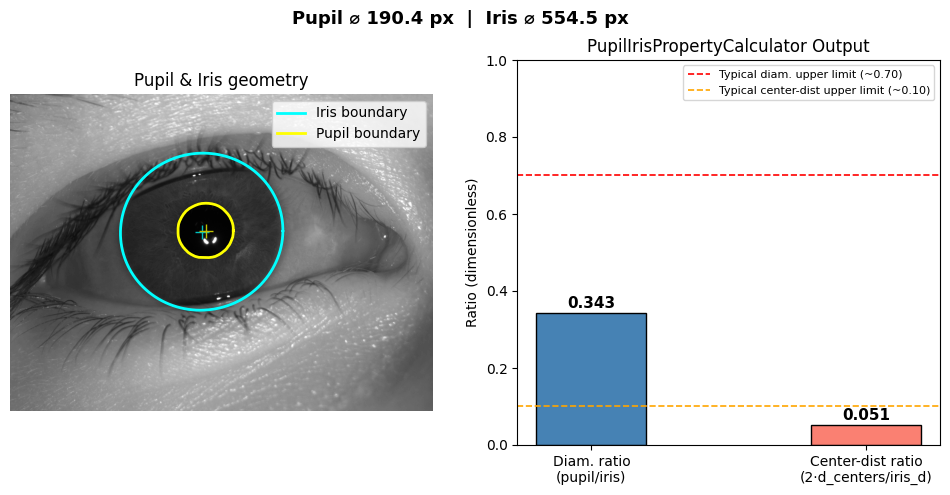

In [ ]:
# ---- Visualization cell ----
pupil_d    = geometry.pupil_diameter
iris_d     = geometry.iris_diameter
diam_ratio = result.pupil_to_iris_diameter_ratio
dist_ratio = result.pupil_to_iris_center_dist_ratio

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel — annotated eye image using polygon arrays
ax = axes[0]
ax.imshow(img_pixels, cmap="gray")
iris_pts  = geometry.iris_array
pupil_pts = geometry.pupil_array
ax.plot(iris_pts[:, 0],  iris_pts[:, 1],  color="cyan",   lw=2, label="Iris boundary")
ax.plot(pupil_pts[:, 0], pupil_pts[:, 1], color="yellow", lw=2, label="Pupil boundary")
cx, cy = iris_pts[:, 0].mean(),  iris_pts[:, 1].mean()
px, py = pupil_pts[:, 0].mean(), pupil_pts[:, 1].mean()
ax.plot(cx, cy, "c+", ms=10)
ax.plot(px, py, "y+", ms=10)
ax.set_title("Pupil & Iris geometry")
ax.legend(loc="upper right")
ax.axis("off")

# Right panel — bar chart of computed ratios (unchanged)
ax2 = axes[1]
labels = ["Diam. ratio\n(pupil/iris)", "Center-dist ratio\n(2·d_centers/iris_d)"]
values = [diam_ratio, dist_ratio]
colors = ["steelblue", "salmon"]
bars = ax2.bar(labels, values, color=colors, width=0.4, edgecolor="black")
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f"{val:.3f}",
             ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.axhline(0.7, color="red",    ls="--", lw=1.2, label="Typical diam. upper limit (~0.70)")
ax2.axhline(0.1, color="orange", ls="--", lw=1.2, label="Typical center-dist upper limit (~0.10)")
ax2.set_ylim(0, 1.0)
ax2.set_ylabel("Ratio (dimensionless)")
ax2.set_title("PupilIrisPropertyCalculator Output")
ax2.legend(fontsize=8)

plt.suptitle(f"Pupil ⌀ {pupil_d:.1f} px  |  Iris ⌀ {iris_d:.1f} px", fontsize=13, fontweight="bold")

#### What to look for

**Good output:**  
- `pupil_to_iris_diameter_ratio` is roughly **0.2 – 0.6** (pupil is well inside the iris; neither fully dilated nor pinpoint).  
- `pupil_to_iris_center_dist_ratio` is close to **0** (pupil center and iris center are nearly co-located).  
- No exception is raised.

**Bad / suspicious output:**  
- A `PupilIrisPropertyEstimationError` is raised — check which condition triggered it (too-small diameter, pupil ≥ iris, or pupil center outside iris).  
- Diameter ratio > 0.8: the pupil almost fills the iris — usually means poor lighting or a segmentation error.  
- Center-distance ratio > 0.15: pupil is noticeably off-center — possible severe off-gaze or segmentation artifact.

---

### Eccentricity Offgaze Estimation
`src/iris/nodes/eye_properties_estimation/`

#### What it does
When a person looks straight at the camera their iris appears circular; as they look away the iris (and pupil) appear progressively more elliptical due to perspective. This node measures that **eccentricity** — a value between 0 (perfect circle) and 1 (perfect line) — for both the iris and pupil polygons, then combines them into a single **offgaze score**. A high score means the user was not looking at the camera and the resulting iris code is less reliable.

#### Key Parameters

| Parameter | Default | What it controls |
|---|---|---|
| `eccentricity_method` | `"moments"` | How eccentricity is computed: `"moments"` (image moments), `"ellipse_fit"` (standard OpenCV), `"ellipse_fit_direct"`, `"ellipse_fit_ams"` |
| `assembling_method` | `"min"` | How pupil & iris eccentricities are combined into one score: `"min"`, `"max"`, `"mean"`, `"only_pupil"`, `"only_iris"` |

In [ ]:
# ---- running EccentricityOffgazeEstimation  ----
from iris.nodes.eye_properties_estimation.eccentricity_offgaze_estimation import EccentricityOffgazeEstimation

node_offgaze = EccentricityOffgazeEstimation(
    eccentricity_method="moments",
    assembling_method="min",
)

offgaze = node_offgaze.run(geometries=geometry)

print("Return type:", type(offgaze))
print(f"Offgaze score: {offgaze.score:.4f}  (0 = looking straight, 1 = extreme off-gaze)")

Return type: <class 'iris.io.dataclasses.Offgaze'>
Offgaze score: 0.0003  (0 = looking straight, 1 = extreme off-gaze)


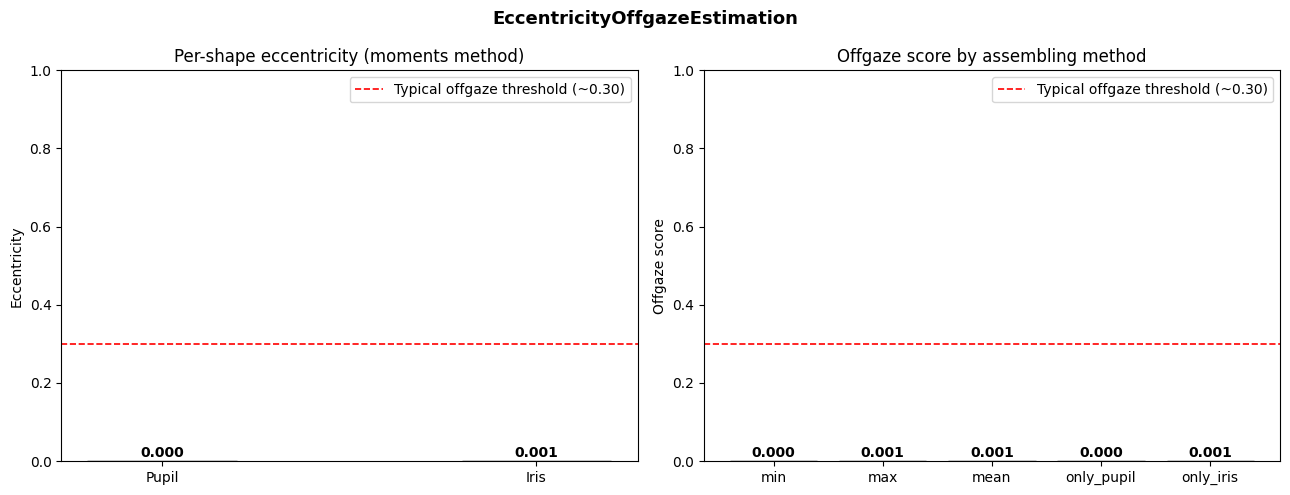

In [ ]:
# ---- Visualization cell: compare all assembling methods ----
from iris.nodes.eye_properties_estimation.eccentricity_offgaze_estimation import (
    get_eccentricity_through_moments,
)

pupil_ecc = get_eccentricity_through_moments(geometry.pupil_array)
iris_ecc  = get_eccentricity_through_moments(geometry.iris_array)

assembling_methods = ["min", "max", "mean", "only_pupil", "only_iris"]
scores = []
for method in assembling_methods:
    n = EccentricityOffgazeEstimation(eccentricity_method="moments", assembling_method=method)
    scores.append(n.run(geometries=geometry).score)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — breakdown: pupil vs iris eccentricity
ax = axes[0]
ax.bar(["Pupil", "Iris"], [pupil_ecc, iris_ecc], color=["gold", "cornflowerblue"], edgecolor="black", width=0.4)
ax.axhline(0.3, color="red", ls="--", lw=1.2, label="Typical offgaze threshold (~0.30)")
ax.set_ylim(0, 1)
ax.set_ylabel("Eccentricity")
ax.set_title("Per-shape eccentricity (moments method)")
ax.legend()
for i, val in enumerate([pupil_ecc, iris_ecc]):
    ax.text(i, val + 0.01, f"{val:.3f}", ha="center", fontweight="bold")

# Right — all assembling methods
ax2 = axes[1]
colors = ["steelblue" if s == min(scores) else "lightsteelblue" for s in scores]
bars = ax2.bar(assembling_methods, scores, color=colors, edgecolor="black")
ax2.axhline(0.3, color="red", ls="--", lw=1.2, label="Typical offgaze threshold (~0.30)")
ax2.set_ylim(0, 1)
ax2.set_ylabel("Offgaze score")
ax2.set_title("Offgaze score by assembling method")
ax2.legend()
for bar, val in zip(bars, scores):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.3f}",
             ha="center", fontweight="bold")

plt.suptitle("EccentricityOffgazeEstimation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### What to look for

**Good output:**  
- Score well below **0.3** — the iris and pupil polygons are roughly circular, indicating the user was looking at the camera.  
- Pupil and iris eccentricities are similar (consistent shapes).

**Bad / suspicious output:**  
- Score above **0.4–0.5**: likely significant off-gaze; the normalized iris strip will be distorted and matching accuracy will drop.  
- Large gap between pupil and iris eccentricity: one shape may be poorly segmented.  
- `"min"` assembling method is the most conservative (hardest to flag as offgaze) and is therefore the default — switching to `"max"` is stricter and will reject more borderline captures.

---

### Occlusion Calculator (quantile_angle = 90°)
`src/iris/nodes/eye_properties_estimation/`

#### What it does
This node computes the **visible fraction of the iris** — the proportion of the iris annulus that is not blocked by eyelids, eyelashes, specular reflections, or other noise. It does this by masking the iris polygon against all accumulated noise masks and counting the ratio of clean pixels to total expected iris pixels. A fraction of 1.0 means a fully open, clean iris; 0.0 means fully occluded. Despite the name "occlusion", the value is actually an *opening* score (higher = more visible).

The `quantile_angle` parameter restricts *which part* of the iris is evaluated. At **90°**, the full iris circle is considered; at smaller angles, only the horizontal band around the equator is considered (less sensitive to eyelid occlusion).

#### Key Parameters

| Parameter | Default | What it controls |
|---|---|---|
| `quantile_angle` | varies (90 or 30) | Angular half-width of the iris zone to evaluate, in degrees. 90 = full iris, 30 = horizontal middle-third only. Must be in [0, 90]. |

In [ ]:
# ---- running OcclusionCalculator (90°) ----
from iris.nodes.eye_properties_estimation.occlusion_calculator import OcclusionCalculator

node_occ90 = OcclusionCalculator(quantile_angle=90.0)

occlusion90 = node_occ90.run(
    extrapolated_polygons=geometry,
    noise_mask=noise_mask,
    eye_orientation=eye_orient,
    eye_centers=eye_centers,
)

print("Return type:", type(occlusion90))
print(f"Visible fraction (90°): {occlusion90.visible_fraction:.4f}  (1 = fully open, 0 = fully occluded)")

Return type: <class 'iris.io.dataclasses.EyeOcclusion'>
Visible fraction (90°): 0.8724  (1 = fully open, 0 = fully occluded)


### Occlusion Calculator (quantile_angle = 30°)

In [ ]:
# ---- running OcclusionCalculator (30°) ----
node_occ30 = OcclusionCalculator(quantile_angle=30.0)

occlusion30 = node_occ30.run(
    extrapolated_polygons=geometry,
    noise_mask=noise_mask,
    eye_orientation=eye_orient,
    eye_centers=eye_centers,
)

print("Return type:", type(occlusion30))
print(f"Visible fraction (30°): {occlusion30.visible_fraction:.4f}  (1 = fully open, 0 = fully occluded)")

Return type: <class 'iris.io.dataclasses.EyeOcclusion'>
Visible fraction (30°): 0.9980  (1 = fully open, 0 = fully occluded)


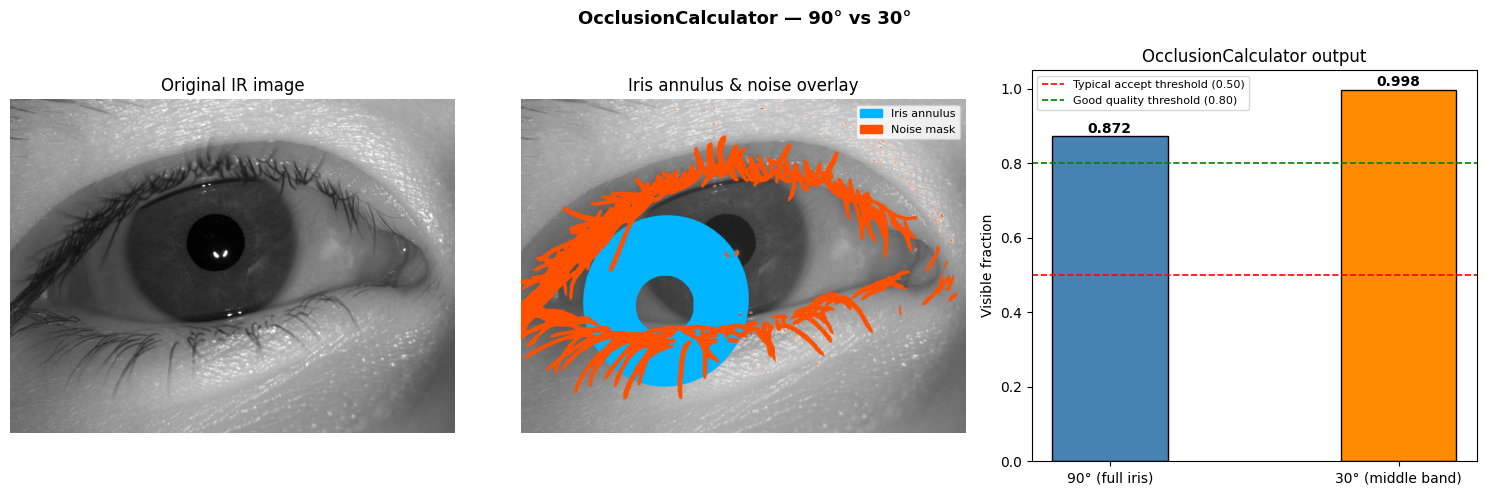

In [ ]:
# ---- Visualization cell: show evaluated iris zones and visible masks ----
from iris.utils import common

img_h, img_w = noise_mask.mask.shape  

def build_iris_annulus_mask(geom):
    """Returns a boolean mask for the iris annulus (iris minus pupil)."""
    iris_m  = common.contour_to_mask(geom.iris_array,  mask_shape=(img_h, img_w))
    pupil_m = common.contour_to_mask(geom.pupil_array, mask_shape=(img_h, img_w))
    if iris_m.shape != (img_h, img_w):
        iris_m  = iris_m.T
    if pupil_m.shape != (img_h, img_w):
        pupil_m = pupil_m.T
    return iris_m & ~pupil_m

annulus_mask = build_iris_annulus_mask(geometry)
visible_mask = annulus_mask & ~noise_mask.mask  

img_display = img_pixels if img_pixels.shape == (img_h, img_w) else img_pixels.T

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1 — raw image
axes[0].imshow(img_display, cmap="gray")
axes[0].set_title("Original IR image")
axes[0].axis("off")

# Panel 2 — iris annulus vs noise overlay
overlay = np.zeros((img_h, img_w, 3), dtype=np.uint8)
overlay[..., 0] = img_display
overlay[..., 1] = img_display
overlay[..., 2] = img_display
overlay[annulus_mask,    0] = 0
overlay[annulus_mask,    1] = 180
overlay[annulus_mask,    2] = 255   # blue = iris annulus
overlay[noise_mask.mask, 0] = 255
overlay[noise_mask.mask, 1] = 80
overlay[noise_mask.mask, 2] = 0     # red = noise
axes[1].imshow(overlay)
iris_patch  = mpatches.Patch(color=(0, 180/255, 1), label="Iris annulus")
noise_patch = mpatches.Patch(color=(1, 80/255,  0), label="Noise mask")
axes[1].legend(handles=[iris_patch, noise_patch], loc="upper right", fontsize=8)
axes[1].set_title("Iris annulus & noise overlay")
axes[1].axis("off")

# Panel 3 — bar comparing 90° vs 30°
angles     = ["90° (full iris)", "30° (middle band)"]
fracs      = [occlusion90.visible_fraction, occlusion30.visible_fraction]
bar_colors = ["steelblue", "darkorange"]
bars = axes[2].bar(angles, fracs, color=bar_colors, edgecolor="black", width=0.4)
axes[2].axhline(0.5, color="red",   ls="--", lw=1.2, label="Typical accept threshold (0.50)")
axes[2].axhline(0.8, color="green", ls="--", lw=1.2, label="Good quality threshold (0.80)")
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel("Visible fraction")
axes[2].set_title("OcclusionCalculator output")
axes[2].legend(fontsize=8)
for bar, val in zip(bars, fracs):
    axes[2].text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.3f}",
                 ha="center", fontweight="bold")

plt.suptitle("OcclusionCalculator — 90° vs 30°", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Aggregation
---
#### NoiseMaskUnion
**Source:** `src/iris/nodes/aggregation/`

#### What it does
Throughout the pipeline, multiple independent processes each produce a boolean noise mask: specular-reflection detection flags bright glare patches, segmentation binarization flags regions outside the iris/pupil boundary, and so on. `NoiseMaskUnion` takes the **logical OR** (union) of all those individual masks into a single combined mask. Any pixel flagged by *any* upstream mask is marked as noise in the output — implemented as `np.sum(...) > 0` across all masks. This single unified mask is then passed to downstream nodes (normalization, occlusion calculator, etc.) so every subsequent step uses a consistent definition of "bad pixels".

#### Key Parameters

| Parameter | Default | What it controls |
|---|---|---|
| *(none)* | — | This node has no configurable parameters; it is purely a logical OR aggregation of its inputs passed as `elements` |

In [23]:
# ── Code cell: run NoiseMaskUnion in isolation ──
from iris.nodes.aggregation.noise_mask_union import NoiseMaskUnion
from iris.io.dataclasses import NoiseMask

node_union = NoiseMaskUnion()

# Only specular_reflection_detection is a clean NoiseMask in the call_trace
# segmentation_binarization is stored as a tuple by the pipeline internals
specular_mask = pipeline.call_trace.get("specular_reflection_detection")

individual_masks = [specular_mask]

print(f"Number of masks being combined: {len(individual_masks)}")
print(f"  specular_reflection_detection: {specular_mask.mask.mean()*100:.2f}% flagged, shape={specular_mask.mask.shape}")

combined = node_union.run(elements=individual_masks)

print(f"\nReturn type: {type(combined)}")
print(f"Combined mask shape: {combined.mask.shape}")
print(f"Fraction of pixels flagged as noise: {combined.mask.mean()*100:.2f}%")

# Compare to the pipeline's own aggregated mask
pipeline_union = pipeline.call_trace.get("noise_masks_aggregation")
print(f"\nPipeline's noise_masks_aggregation: {pipeline_union.mask.mean()*100:.2f}% flagged")
print("(Higher % expected — pipeline combines more masks including segmentation binarization)")

Number of masks being combined: 1
  specular_reflection_detection: 0.13% flagged, shape=(1080, 1440)

Return type: <class 'iris.io.dataclasses.NoiseMask'>
Combined mask shape: (1080, 1440)
Fraction of pixels flagged as noise: 0.13%

Pipeline's noise_masks_aggregation: 14.05% flagged
(Higher % expected — pipeline combines more masks including segmentation binarization)


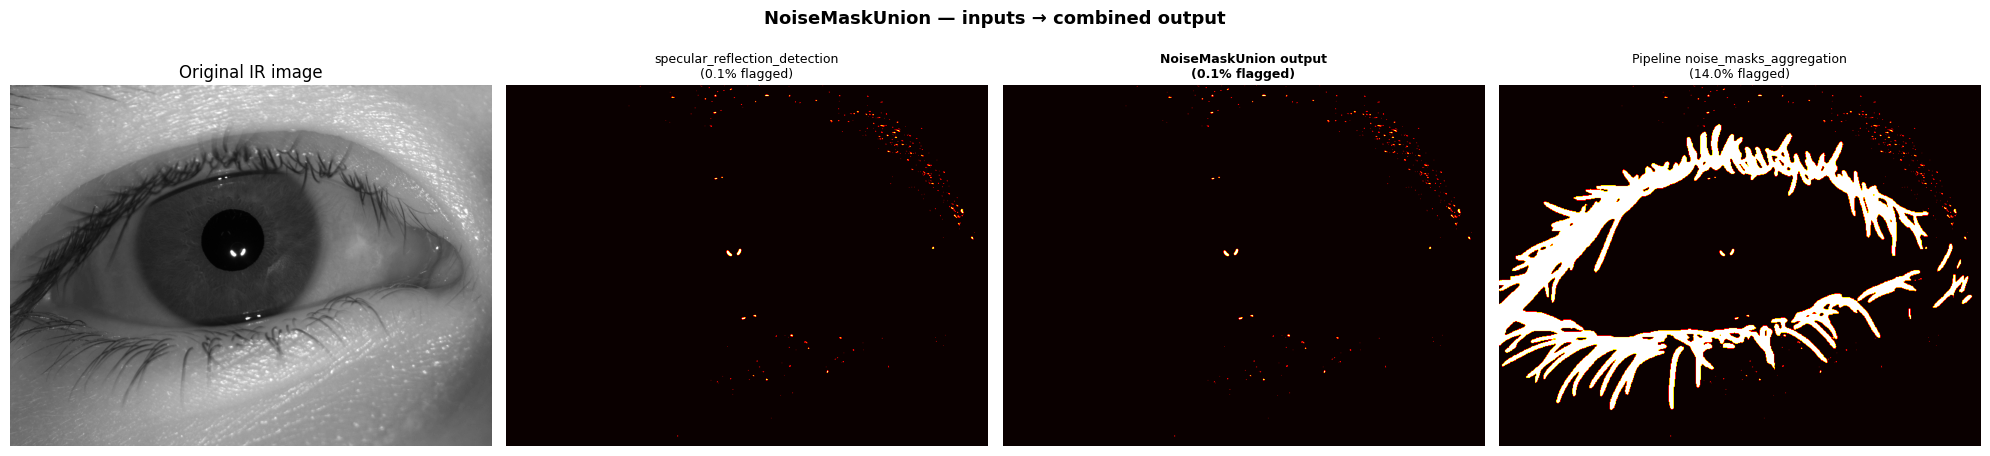

Sanity check: union must be superset of every individual input
Sanity check passed ✓


In [24]:
# ── Visualization cell: show individual mask, our union, and pipeline union ──
ref_h, ref_w = specular_mask.mask.shape
img_display = img_pixels if img_pixels.shape == (ref_h, ref_w) else img_pixels.T

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Panel 1 — original image
axes[0].imshow(img_display, cmap="gray")
axes[0].set_title("Original IR image")
axes[0].axis("off")

# Panel 2 — specular reflection mask
axes[1].imshow(specular_mask.mask, cmap="hot", vmin=0, vmax=1)
axes[1].set_title(f"specular_reflection_detection\n({specular_mask.mask.mean()*100:.1f}% flagged)", fontsize=9)
axes[1].axis("off")

# Panel 3 — our NoiseMaskUnion output
axes[2].imshow(combined.mask, cmap="hot", vmin=0, vmax=1)
axes[2].set_title(f"NoiseMaskUnion output\n({combined.mask.mean()*100:.1f}% flagged)", fontsize=9, fontweight="bold")
axes[2].axis("off")

# Panel 4 — pipeline's full aggregation for comparison
axes[3].imshow(pipeline_union.mask, cmap="hot", vmin=0, vmax=1)
axes[3].set_title(f"Pipeline noise_masks_aggregation\n({pipeline_union.mask.mean()*100:.1f}% flagged)", fontsize=9)
axes[3].axis("off")

plt.suptitle("NoiseMaskUnion — inputs → combined output", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Sanity check: union must be superset of every individual input")
assert (~specular_mask.mask | combined.mask).all(), "Union is missing pixels from specular mask!"
print("Sanity check passed ✓")

## Validators
---
### Pupil2IrisPropertyValidator
`src/iris/nodes/validators/object_validators.py`

#### What it does
This validator checks that the pupil-to-iris ratios computed by `PupilIrisPropertyCalculator` fall within acceptable bounds. It raises three distinct errors

#### Key Parameters

| Parameter | Default | What it controls |
|---|---|---|
| `min_allowed_diameter_ratio` | `0.0001` | Minimum pupil/iris diameter ratio; below this the pupil is considered too constricted |
| `max_allowed_diameter_ratio` | `0.9999` | Maximum pupil/iris diameter ratio; above this the pupil is considered too dilated |
| `max_allowed_center_dist_ratio` | `0.9999` | Maximum allowed pupil-center to iris-center distance ratio; above this the pupil is considered off-center |

In [26]:
# ── Code cell: run Pupil2IrisPropertyValidator in isolation ──
from iris.nodes.validators.object_validators import Pupil2IrisPropertyValidator
import iris.io.errors as E

p2i_result = pipeline.call_trace.get("pupil_to_iris_property_estimation")

print(f"Input values:")
print(f"  pupil_to_iris_diameter_ratio  : {p2i_result.pupil_to_iris_diameter_ratio:.4f}")
print(f"  pupil_to_iris_center_dist_ratio: {p2i_result.pupil_to_iris_center_dist_ratio:.4f}")

# Test with permissive defaults
validator = Pupil2IrisPropertyValidator()
try:
    validator.run(val_arguments=p2i_result)
    print("\nDefault thresholds: PASSED ✓")
except (E.Pupil2IrisValidatorErrorConstriction, E.Pupil2IrisValidatorErrorDilation, E.Pupil2IrisValidatorErrorOffcenter) as e:
    print(f"\nDefault thresholds: FAILED — {e}")

# Test with strict thresholds to demonstrate failure modes
strict_validator = Pupil2IrisPropertyValidator(
    min_allowed_diameter_ratio=0.4,
    max_allowed_diameter_ratio=0.6,
    max_allowed_center_dist_ratio=0.05,
)
try:
    strict_validator.run(val_arguments=p2i_result)
    print("Strict thresholds:  PASSED ✓")
except E.Pupil2IrisValidatorErrorConstriction as e:
    print(f"Strict thresholds:  FAILED (constriction) — {e}")
except E.Pupil2IrisValidatorErrorDilation as e:
    print(f"Strict thresholds:  FAILED (dilation) — {e}")
except E.Pupil2IrisValidatorErrorOffcenter as e:
    print(f"Strict thresholds:  FAILED (off-center) — {e}")

Input values:
  pupil_to_iris_diameter_ratio  : 0.3434
  pupil_to_iris_center_dist_ratio: 0.0509

Default thresholds: PASSED ✓
Strict thresholds:  FAILED (constriction) — p2i_property=0.34343639019155825 is below min threshold 0.4. Pupil is too constricted.


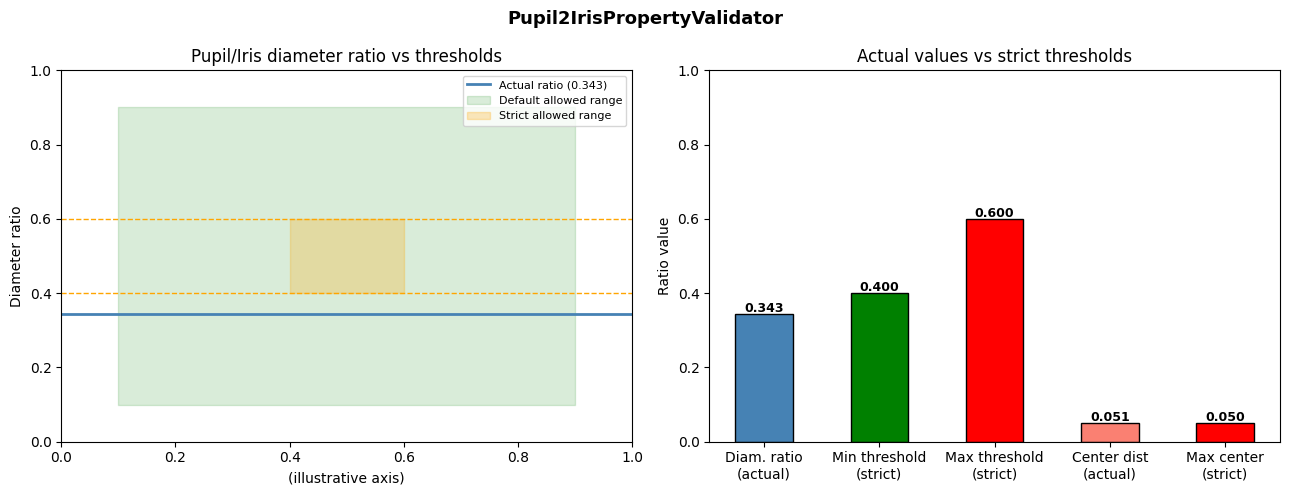

In [27]:
# ── Visualization cell ──
diam_ratio = p2i_result.pupil_to_iris_diameter_ratio
dist_ratio = p2i_result.pupil_to_iris_center_dist_ratio

# Sweep thresholds to show pass/fail boundaries
diam_thresholds = np.linspace(0.01, 0.99, 50)
diam_pass = [
    min_t < diam_ratio < max_t
    for min_t in diam_thresholds
    for max_t in [0.9999]
]
min_thresholds = np.linspace(0.01, diam_ratio, 50)
max_thresholds = np.linspace(diam_ratio, 0.99, 50)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — diameter ratio vs allowed range
ax = axes[0]
ax.axhline(diam_ratio, color="steelblue", lw=2, label=f"Actual ratio ({diam_ratio:.3f})")
ax.fill_between([0.1, 0.9], [0.1, 0.1], [0.9, 0.9], alpha=0.15, color="green", label="Default allowed range")
ax.fill_between([0.4, 0.6], [0.4, 0.4], [0.6, 0.6], alpha=0.25, color="orange", label="Strict allowed range")
ax.axhline(0.4, color="orange", ls="--", lw=1)
ax.axhline(0.6, color="orange", ls="--", lw=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("(illustrative axis)")
ax.set_ylabel("Diameter ratio")
ax.set_title("Pupil/Iris diameter ratio vs thresholds")
ax.legend(fontsize=8)

# Right — bar chart: actual values vs strict thresholds
ax2 = axes[1]
metrics = ["Diam. ratio\n(actual)", "Min threshold\n(strict)", "Max threshold\n(strict)", "Center dist\n(actual)", "Max center\n(strict)"]
values  = [diam_ratio, 0.4, 0.6, dist_ratio, 0.05]
colors  = ["steelblue", "green", "red", "salmon", "red"]
bars = ax2.bar(metrics, values, color=colors, edgecolor="black", width=0.5)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f"{val:.3f}",
             ha="center", fontsize=9, fontweight="bold")
ax2.set_ylim(0, 1.0)
ax2.set_ylabel("Ratio value")
ax2.set_title("Actual values vs strict thresholds")

plt.suptitle("Pupil2IrisPropertyValidator", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### What to look for

**Good output:**  
- Both validators pass with no exception raised.  
- Diameter ratio is comfortably between `min` and `max` thresholds — not near either boundary.  
- Center distance ratio is well below the max — pupil and iris are concentric.

**Bad / suspicious output:**  
- `Pupil2IrisValidatorErrorConstriction`: pupil diameter is abnormally small — check lighting or segmentation.  
- `Pupil2IrisValidatorErrorDilation`: pupil almost fills the iris — extreme dilation or segmentation error.  
- `Pupil2IrisValidatorErrorOffcenter`: centers are far apart — likely severe off-gaze or a geometry estimation failure upstream.

---

### OffgazeValidator
`src/iris/nodes/validators/object_validators.py`

#### What it does
This validator takes the offgaze score produced by `EccentricityOffgazeEstimation` and checks it against a maximum threshold. If the score exceeds `max_allowed_offgaze` the image is rejected — the user was not looking at the camera and the iris code would be unreliable. Like all validators it returns `None` on success and raises `OffgazeEstimationError` on failure.

#### Key Parameters

| Parameter | Default | What it controls |
|---|---|---|
| `max_allowed_offgaze` | `1.0` | Maximum allowed offgaze score (0–1). Default of 1.0 means every image passes; lower values enforce stricter gaze requirements. |

In [28]:
# ── Code cell: run OffgazeValidator in isolation ──
from iris.nodes.validators.object_validators import OffgazeValidator

offgaze_result = pipeline.call_trace.get("offgaze_estimation")
print(f"Offgaze score: {offgaze_result.score:.4f}")

# Permissive default
validator = OffgazeValidator(max_allowed_offgaze=1.0)
try:
    validator.run(val_arguments=offgaze_result)
    print("Default threshold (1.0): PASSED ✓")
except E.OffgazeEstimationError as e:
    print(f"Default threshold (1.0): FAILED — {e}")

# Sweep thresholds to find the tipping point
print("\nThreshold sweep:")
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:
    v = OffgazeValidator(max_allowed_offgaze=threshold)
    try:
        v.run(val_arguments=offgaze_result)
        print(f"  max_allowed_offgaze={threshold}: PASSED ✓")
    except E.OffgazeEstimationError:
        print(f"  max_allowed_offgaze={threshold}: FAILED ✗")

Offgaze score: 0.0003
Default threshold (1.0): PASSED ✓

Threshold sweep:
  max_allowed_offgaze=0.1: PASSED ✓
  max_allowed_offgaze=0.2: PASSED ✓
  max_allowed_offgaze=0.3: PASSED ✓
  max_allowed_offgaze=0.4: PASSED ✓
  max_allowed_offgaze=0.5: PASSED ✓


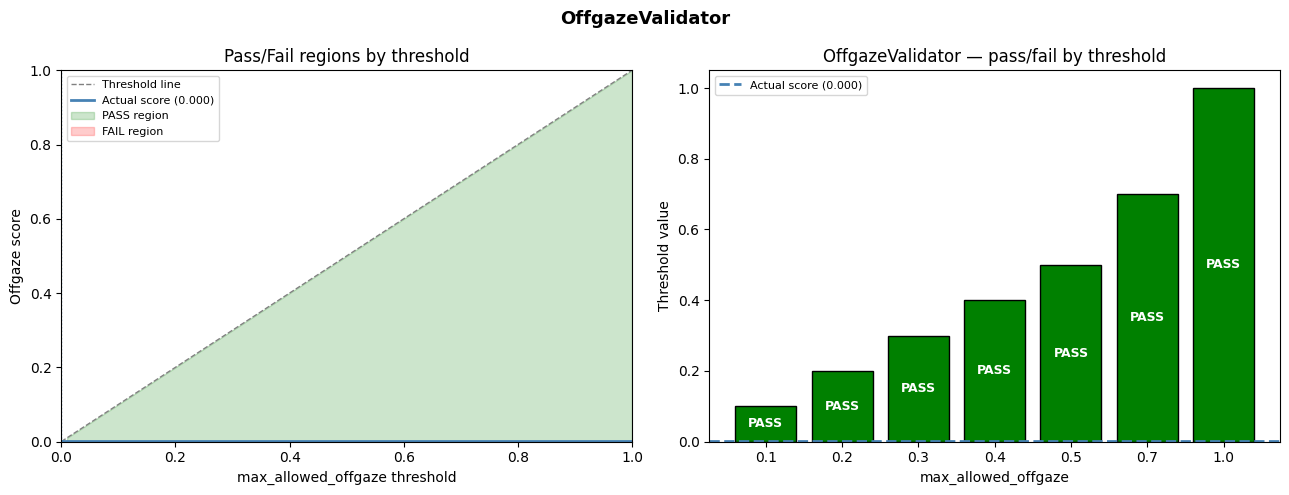

In [29]:
# ── Visualization cell ──
score = offgaze_result.score
thresholds = np.linspace(0.0, 1.0, 100)
pass_fail   = ["PASS" if score <= t else "FAIL" for t in thresholds]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — score vs threshold sweep line
ax = axes[0]
ax.plot(thresholds, thresholds, color="gray", lw=1, ls="--", label="Threshold line")
ax.axhline(score, color="steelblue", lw=2, label=f"Actual score ({score:.3f})")
ax.axvline(score, color="steelblue", lw=1, ls=":")
ax.fill_between(thresholds, score, thresholds,
                where=[t >= score for t in thresholds],
                alpha=0.2, color="green", label="PASS region")
ax.fill_between(thresholds, score, thresholds,
                where=[t < score for t in thresholds],
                alpha=0.2, color="red", label="FAIL region")
ax.set_xlabel("max_allowed_offgaze threshold")
ax.set_ylabel("Offgaze score")
ax.set_title("Pass/Fail regions by threshold")
ax.legend(fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Right — bar at specific thresholds
check_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]
bar_colors = ["green" if score <= t else "red" for t in check_thresholds]
bars = axes[1].bar([str(t) for t in check_thresholds], check_thresholds,
                   color=bar_colors, edgecolor="black")
axes[1].axhline(score, color="steelblue", lw=2, ls="--", label=f"Actual score ({score:.3f})")
for bar, t, c in zip(bars, check_thresholds, bar_colors):
    label = "PASS" if score <= t else "FAIL"
    axes[1].text(bar.get_x() + bar.get_width() / 2, t / 2, label,
                 ha="center", va="center", fontsize=9, fontweight="bold", color="white")
axes[1].set_xlabel("max_allowed_offgaze")
axes[1].set_ylabel("Threshold value")
axes[1].set_title("OffgazeValidator — pass/fail by threshold")
axes[1].legend(fontsize=8)

plt.suptitle("OffgazeValidator", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### What to look for

**Good output:**  
- Score well below your chosen `max_allowed_offgaze` — comfortable margin from the threshold.  
- For production use, a threshold of **0.3–0.45** is typical; the default of 1.0 accepts everything.

**Bad / suspicious output:**  
- Score very close to the threshold: borderline capture — consider re-acquiring.  
- Score above 0.5: significant off-gaze; the iris code will be distorted and matching accuracy will degrade.

---

### `OcclusionValidator
`src/iris/nodes/validators/object_validators.py`

#### What it does
This validator checks that the iris visible fraction computed by `OcclusionCalculator` meets a minimum threshold. If too much of the iris is covered by eyelids, eyelashes, or reflections the image is rejected by raising `OcclusionError`. It is typically run twice in the pipeline — once for the 90° zone and once for the 30° zone — with different thresholds for each.

#### Key Parameters

| Parameter | Default | What it controls |
|---|---|---|
| `min_allowed_occlusion` | `0.0` | Minimum required visible iris fraction (0–1). Default of 0.0 accepts everything; increase to enforce minimum eye openness. |

In [30]:
# ── Code cell: run OcclusionValidator in isolation ──
from iris.nodes.validators.object_validators import OcclusionValidator

occ90_result = pipeline.call_trace.get("occlusion90_calculator")
occ30_result = pipeline.call_trace.get("occlusion30_calculator")

print(f"Visible fraction (90°): {occ90_result.visible_fraction:.4f}")
print(f"Visible fraction (30°): {occ30_result.visible_fraction:.4f}")

for label, result in [("90°", occ90_result), ("30°", occ30_result)]:
    print(f"\n{label} threshold sweep:")
    for threshold in [0.3, 0.5, 0.7, 0.9, 0.99]:
        v = OcclusionValidator(min_allowed_occlusion=threshold)
        try:
            v.run(val_arguments=result)
            print(f"  min_allowed_occlusion={threshold}: PASSED ✓")
        except E.OcclusionError:
            print(f"  min_allowed_occlusion={threshold}: FAILED ✗")

Visible fraction (90°): 0.8730
Visible fraction (30°): 0.9980

90° threshold sweep:
  min_allowed_occlusion=0.3: PASSED ✓
  min_allowed_occlusion=0.5: PASSED ✓
  min_allowed_occlusion=0.7: PASSED ✓
  min_allowed_occlusion=0.9: FAILED ✗
  min_allowed_occlusion=0.99: FAILED ✗

30° threshold sweep:
  min_allowed_occlusion=0.3: PASSED ✓
  min_allowed_occlusion=0.5: PASSED ✓
  min_allowed_occlusion=0.7: PASSED ✓
  min_allowed_occlusion=0.9: PASSED ✓
  min_allowed_occlusion=0.99: PASSED ✓


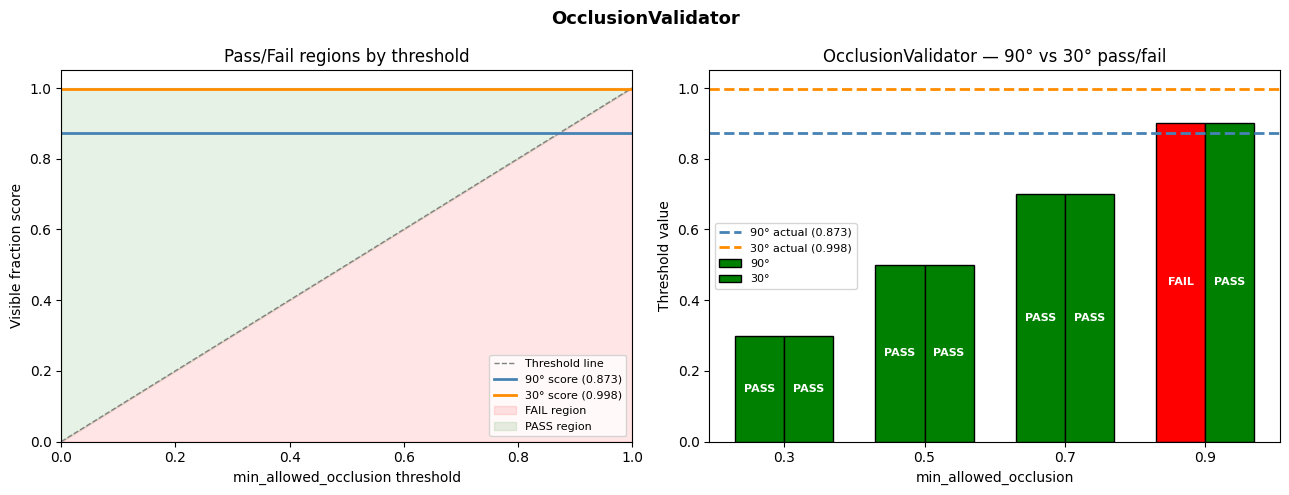

In [31]:
# ── Visualization cell ──
frac90 = occ90_result.visible_fraction
frac30 = occ30_result.visible_fraction
thresholds   = np.linspace(0.0, 1.0, 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — both scores vs threshold sweep
ax = axes[0]
ax.plot(thresholds, thresholds, color="gray", lw=1, ls="--", label="Threshold line")
ax.axhline(frac90, color="steelblue",  lw=2, label=f"90° score ({frac90:.3f})")
ax.axhline(frac30, color="darkorange", lw=2, label=f"30° score ({frac30:.3f})")
ax.fill_between(thresholds, 0, thresholds, alpha=0.1, color="red",   label="FAIL region")
ax.fill_between(thresholds, thresholds, 1, alpha=0.1, color="green", label="PASS region")
ax.set_xlabel("min_allowed_occlusion threshold")
ax.set_ylabel("Visible fraction score")
ax.set_title("Pass/Fail regions by threshold")
ax.legend(fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

# Right — grouped bars at specific thresholds
check_thresholds = [0.3, 0.5, 0.7, 0.9]
x = np.arange(len(check_thresholds))
width = 0.35
bars90 = axes[1].bar(x - width/2, check_thresholds,
                     color=["green" if frac90 >= t else "red" for t in check_thresholds],
                     width=width, edgecolor="black", label="90°")
bars30 = axes[1].bar(x + width/2, check_thresholds,
                     color=["green" if frac30 >= t else "red" for t in check_thresholds],
                     width=width, edgecolor="black", label="30°")
axes[1].axhline(frac90, color="steelblue",  lw=2, ls="--", label=f"90° actual ({frac90:.3f})")
axes[1].axhline(frac30, color="darkorange", lw=2, ls="--", label=f"30° actual ({frac30:.3f})")
for bars, frac in [(bars90, frac90), (bars30, frac30)]:
    for bar, t in zip(bars, check_thresholds):
        label = "PASS" if frac >= t else "FAIL"
        axes[1].text(bar.get_x() + bar.get_width() / 2, t / 2, label,
                     ha="center", va="center", fontsize=8, fontweight="bold", color="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(t) for t in check_thresholds])
axes[1].set_xlabel("min_allowed_occlusion")
axes[1].set_ylabel("Threshold value")
axes[1].set_title("OcclusionValidator — 90° vs 30° pass/fail")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 1.05)

plt.suptitle("OcclusionValidator", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### What to look for

**Good output:**  
- Both 90° and 30° scores comfortably exceed your `min_allowed_occlusion` threshold.  
- Typical production thresholds are **0.5 for 90°** and **0.7 for 30°** — the middle band should be cleaner than the full iris.  
- 30° score ≥ 90° score is the normal relationship (middle band less occluded than full iris).

**Bad / suspicious output:**  
- `OcclusionError` raised: too much of the iris is blocked — heavy eyelid droop, extreme blink, or large specular reflection.  
- 30° score lower than 90°: unusual — suggests the center of the iris is obscured, possibly by a large glare spot.  
- Both scores near 0: likely a complete blink or severe segmentation failure upstream.

---